In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re

In [2]:
out_dir = '.'
devices = ['cpu', 'gpu_h200']

# Format: (marker, color, label)
SOLVERS = ['dq_basic', 'cayley']
solver_style = {
    'dq_basic': ('s', '#2a78d6', 'Basic (Dynamiqs)'),
    'cayley'  : ('^', '#008300', 'Cayley (Dynamiqs)')
}

# Read the data
data = {}
for device in devices:
    data[device] = np.load(f'{out_dir}/{device}.npy', allow_pickle=True).item()

In [3]:
def collect(data_for_method, key='', avg_type='median', breakdown=False):
    """ Collect stats for a given key. """
    if not key:
        return np.array([]), np.array([]), np.array([])

    dims = sorted(data_for_method.keys())
    avg_func = np.median if avg_type == 'median' else np.mean
    valid_dims, avgs, all_values = [], [], []
    
    for d in dims:
        # skip dims that don't have any data
        if d not in data_for_method:
            continue

        # Get the values
        if breakdown:
            vals = [row['op_self_ns'][key] for row in data_for_method[d]]
        else:
            vals = [row[key] for row in data_for_method[d]]
        valid_dims.append(d)
        avgs.append(avg_func(vals))
        all_values.append(vals)
    return np.array(valid_dims), np.array(avgs), np.array(all_values)

def collect_breakdown(data_for_method, avg_type='mean', top_n=7):
    """ Collect stats for all keys in the 'op_self_ns' breakdown. """
    
    dims = sorted(data_for_method.keys())
    
    per_dim = []
    totals = {}
    for d in dims:
        rows = data_for_method[d]
        
        # go through all the runs (time stored in ms)
        mean_wall_time = {}
        for r in rows:
            for op, time in r['op_self_ns'].items():
                op_key = re.sub(r'\.\d+$', '', op)
                mean_wall_time[op_key] = mean_wall_time.get(op_key, 0.0) + time / len(rows) / 1e6
        per_dim.append(mean_wall_time)
        
        # add up the time across dimensions
        for op_key, time in mean_wall_time.items():
            totals[op_key] = totals.get(op_key, 0.0) + time

    # get the top_n operations by total time
    top = [op for op, _ in sorted(totals.items(), key=lambda kv: kv[1], reverse=True)[:top_n]]

    # essentially, transpose to get time vs. dim for each op
    table = {op: np.array([d.get(op, 0.0) for d in per_dim]) for op in top}

    # get the "other" category, which is the sum of all ops not in the top_n
    table['other'] = np.array([sum(v for k, v in d.items() if k not in top) for d in per_dim])

    return dims, table

def any_row_has_key(runs_by_method, key):
    return any(
        key in row
        for data_for_method in runs_by_method.values()
        for rows in data_for_method.values()
        for row in rows
    )

# Plot runtime and memory consumption

In [4]:
def plot_series(ax, d_arr, avgs, all_values, marker, label, color, linestyle='-', alpha=1):
    if len(d_arr) == 0:
        return
    line, = ax.plot(d_arr, avgs, marker=marker, linestyle=linestyle, label=label, 
                    color=color, alpha=alpha)
    for d, vals in zip(d_arr, all_values):
        ax.scatter([d] * len(vals), vals, marker=marker, color=color, alpha=0.25, s=15, zorder=3)

def style_axis(ax, dims, title, ylabel, fontsize):
    ax.set_xlabel('Dimension $d$', fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xticks(dims)
    ax.set_xticklabels(dims, rotation=45, ha='right')
    ax.tick_params(axis='both', labelsize=fontsize)
    ax.set_title(title, fontsize=fontsize)

def plot_compare_runs(device_data, suptitle="", figsize=(6*2.5, (3/4)*6*2), fontsize=12):

    fig, axs = plt.subplots(1, 3, figsize=(6*3, (3/4)*6), constrained_layout=True)
    axs = axs.flatten()

    panels = [
        (axs[0], 't_total',   'Time (s)',          'Wall time vs. dimension'),
        (axs[1], 'mem_total', 'Memory Host (MB)',  'Memory Host vs. dimension'),
        (axs[2], 'mem_gpu',   'Memory GPU (MB)',   'Memory GPU vs. dimension'),
    ]

    # For each panel
    for ax, key, ylabel, title in panels:

        # skip if no runs have this key
        if not any_row_has_key(device_data, key):
            ax.text(0.5, 0.5, f'{key} not found in any runs',
                 ha='center', va='center', 
                 transform=ax.transAxes, color='gray', fontsize=fontsize)
        
        # if found, plot the data for each method
        else:
            for method, (marker, color, label) in solver_style.items():
                dims, avgs, data = collect(device_data[method], key)
                plot_series(ax, dims, avgs, data, marker=marker, color=color, label=label)

        # style
        style_axis(ax, dims, title, ylabel, fontsize)

    # All subplots share the same method legend; show it once to the right of the figure.
    handles, labels = [], []
    for ax in axs:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    fig.legend(handles, labels, loc='outside right center', fontsize=fontsize)

    if suptitle:
        fig.suptitle(suptitle, fontsize=1.5*fontsize)
    
    plt.show()

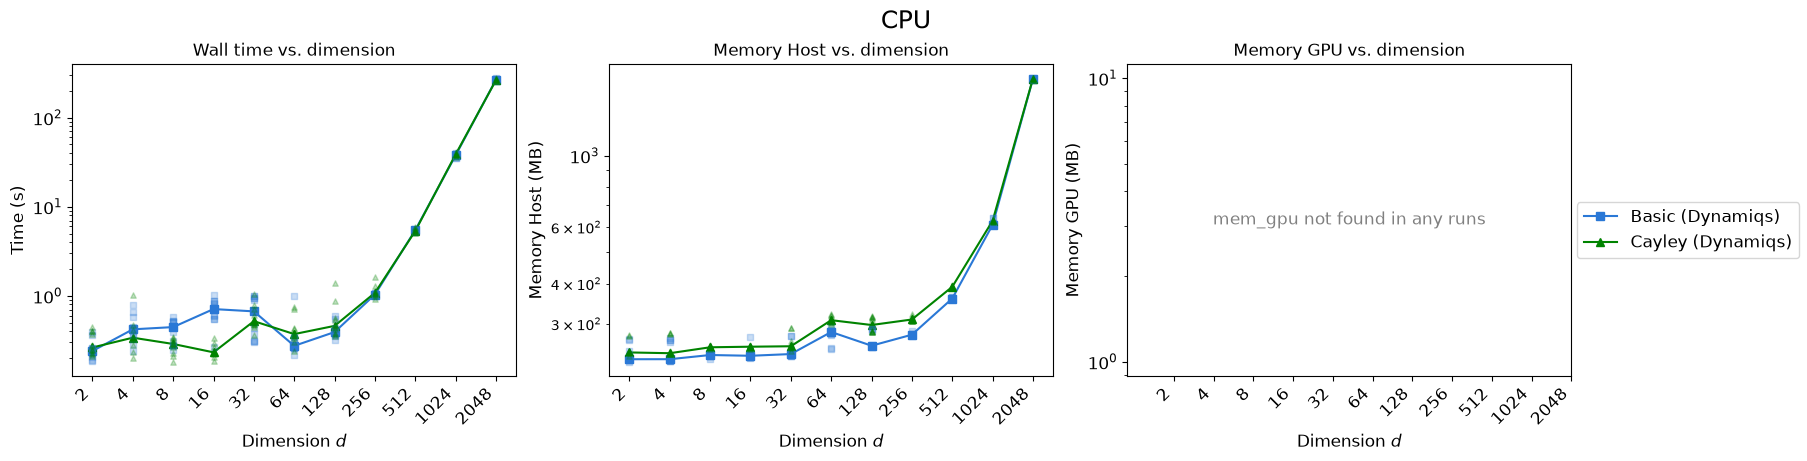

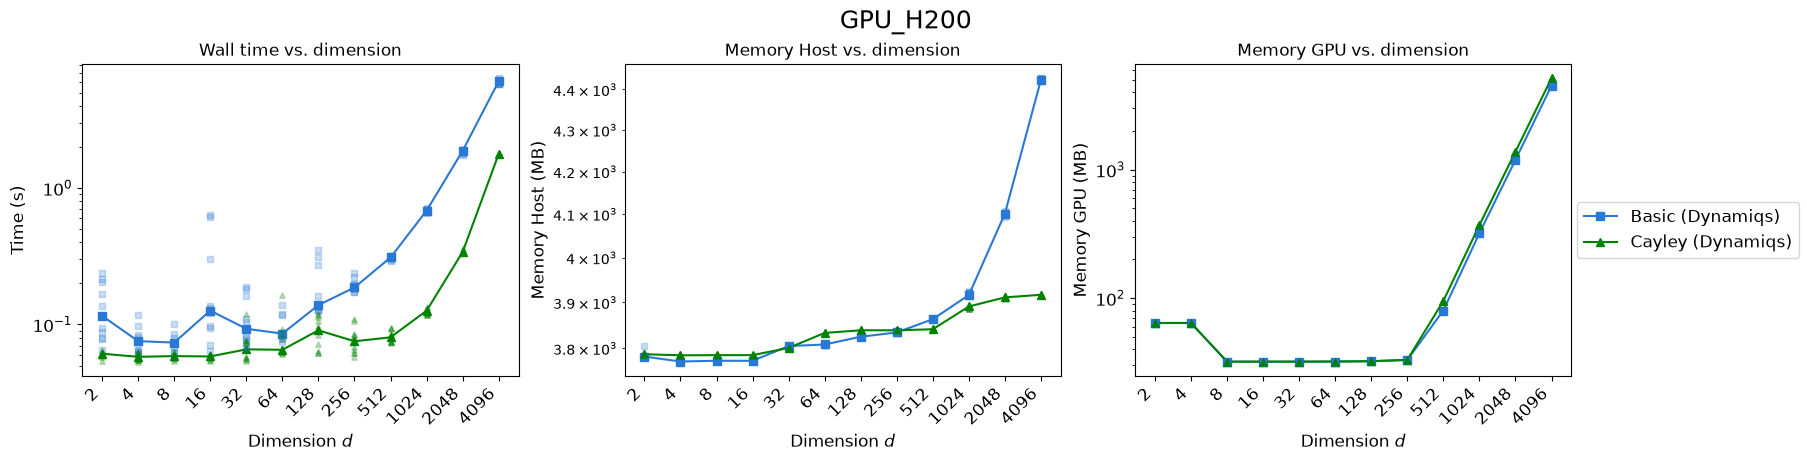

In [5]:
for device in devices:
    plot_compare_runs(data[device], suptitle=f'{device.upper()}')

## Bottleneck breakdown by HLO op category

In [6]:
def plot_breakdown(data_for_device, suptitle="", fontsize=12, normalize=False, 
                   top_n=7, without_command_buffer=False):

    # OP_COLORS = ['#2a78d6', '#008300', '#e87ba4', '#eda100',
    #             '#1baf7a', '#eb6834', '#4a3aa7']
    OP_COLORS = [
        v for k, v in mcolors.TABLEAU_COLORS.items() if k != 'tab:gray'
    ]
    OTHER_COLOR = '#9c9b93'

    fig, axs = plt.subplots(1, len(SOLVERS), 
                            figsize=(6 * len(SOLVERS), 4.5), sharey=False, 
                            constrained_layout=True)
    if len(SOLVERS) == 1:
        axs = [axs]

    for ax, solver in zip(axs, SOLVERS):
        dims, table = collect_breakdown(data_for_device[solver], top_n=top_n)
        x = np.arange(len(dims))
        
        # stacked bar chart (make sure 'other' is last)
        bottom = np.zeros(len(dims))
        ops = [op for op in table 
                if op != 'other' and (
                    not op.startswith('command_buffer') or not without_command_buffer
                )]
        ops += ['other']
        # cycle colors so the list always matches len(ops), even if top_n exceeds len(OP_COLORS)
        colors = [OP_COLORS[i % len(OP_COLORS)] for i in range(len(ops) - 1)] + [OTHER_COLOR]

        # total only over the ops actually being plotted, so normalized shares add up to 100%
        totals = sum(table[op] for op in ops)

        for op, c in zip(ops, colors):
            if normalize:
                share = np.divide(table[op], totals, out=np.zeros_like(totals), where=totals > 0) * 100
            else:
                share = table[op]

            ax.bar(x, share, bottom=bottom, width=0.7, color=c, label=op, 
                   edgecolor='white', linewidth=0.5)
            bottom += share

        ax.set_xlabel('Dimension $d$', fontsize=fontsize)
        ax.set_xticks(x)
        ax.set_xticklabels(dims, rotation=45, ha='right')
        ax.tick_params(axis='both', labelsize=fontsize)
        ax.set_title(solver, fontsize=fontsize)
        ax.legend(fontsize=fontsize, loc='upper left')
        ax.grid(True, axis='y', alpha=0.4)

    if normalize:
        axs[0].set_ylabel('Device time (%)', fontsize=fontsize)
    else:
        axs[0].set_ylabel('Device time (ms)', fontsize=fontsize)

    if suptitle:
        fig.suptitle(suptitle, fontsize=1.5*fontsize)

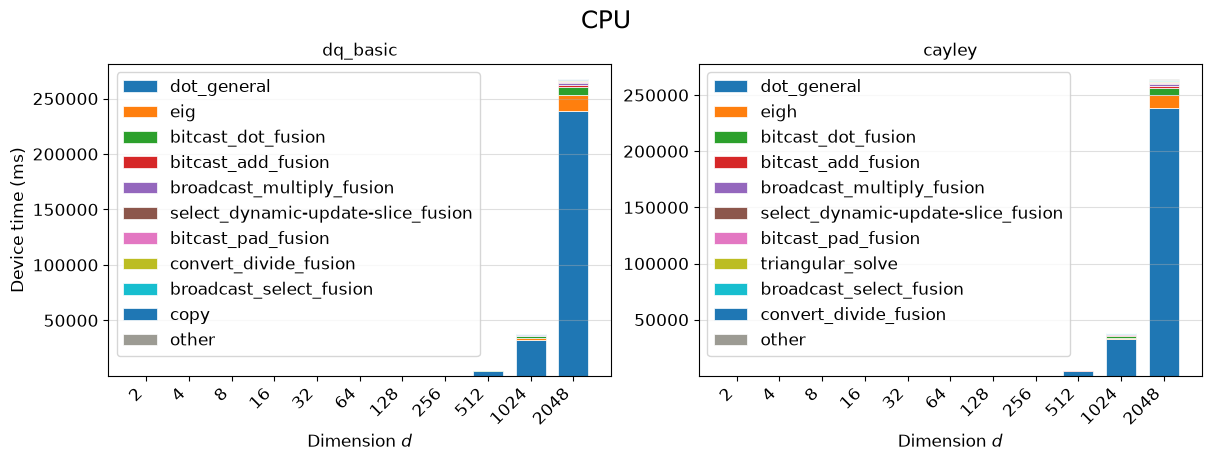

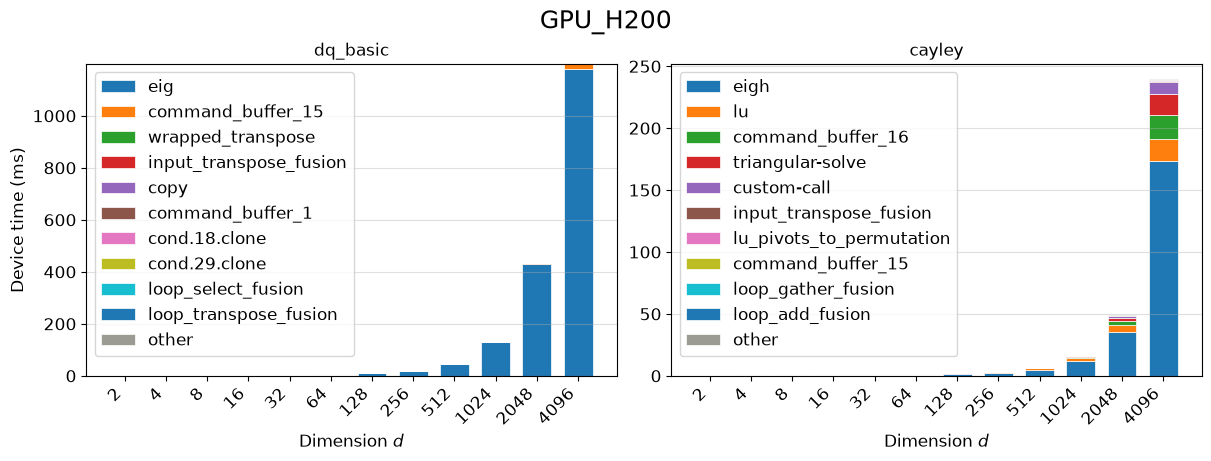

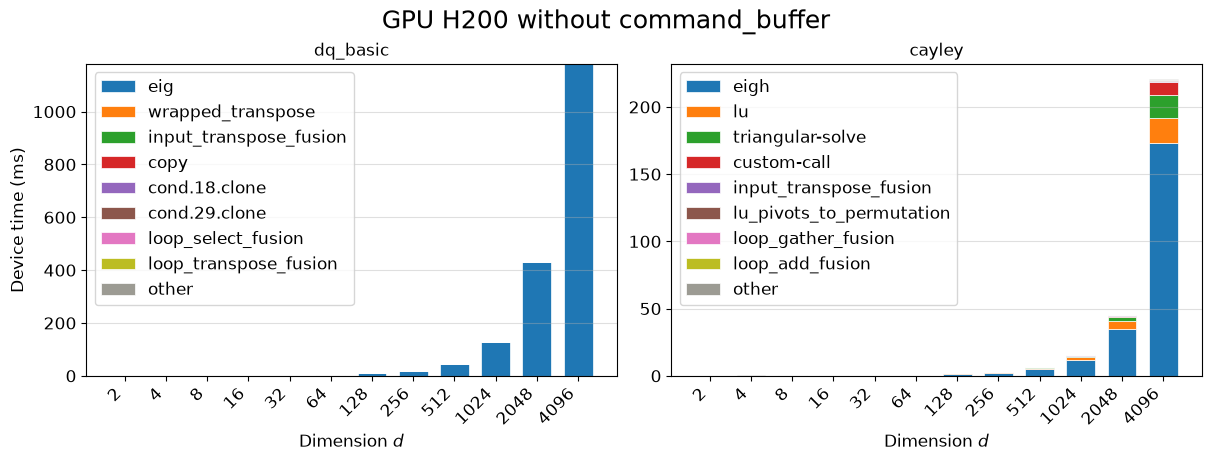

In [7]:
for device in devices:
    plot_breakdown(data[device], suptitle=f'{device.upper()}', top_n=10)

plot_breakdown(data['gpu_h200'], suptitle=f'GPU H200 without command_buffer', top_n=10, 
                without_command_buffer=True)

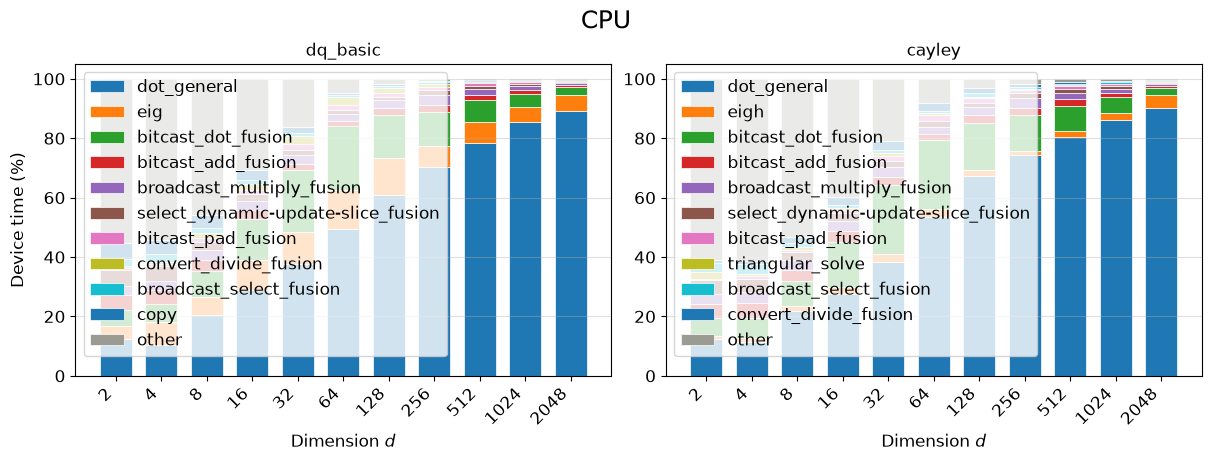

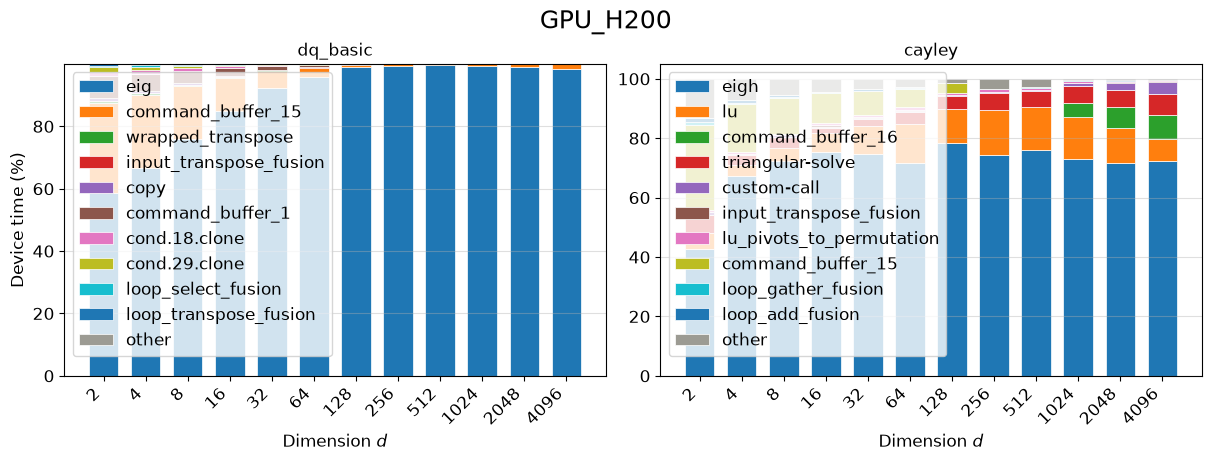

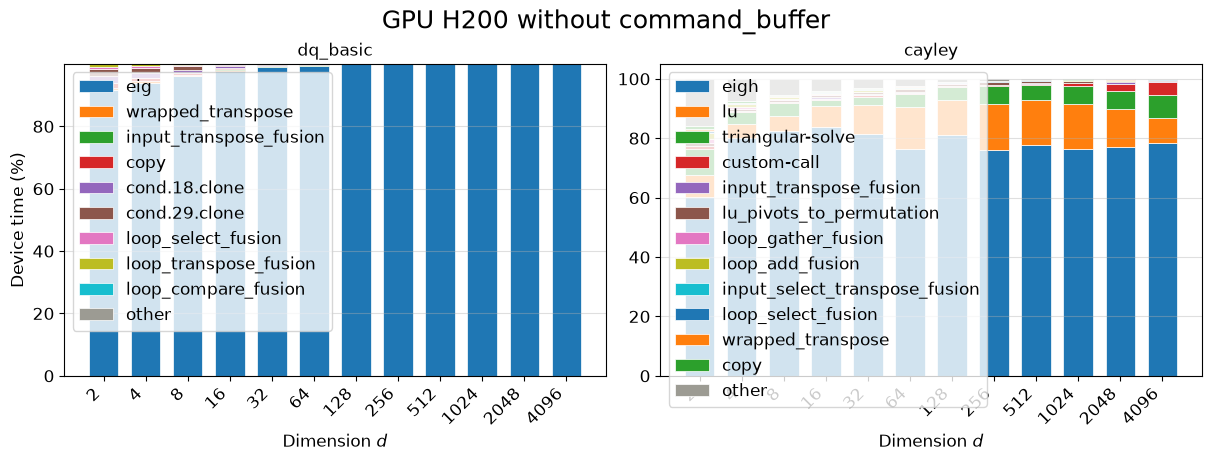

In [8]:
for device in devices:
    plot_breakdown(data[device], suptitle=f'{device.upper()}', normalize=True, top_n=10)

plot_breakdown(data['gpu_h200'], suptitle=f'GPU H200 without command_buffer', top_n=15, 
                without_command_buffer=True, normalize=True)

## How the general `eig` hurts — twice over

`dq_basic` diagonalizes the propagator with a **general** eigendecomposition (`U._eig()`), while
`cayley` maps the problem to a Hermitian one and uses `eigh`. The bars below decompose mean
wall time into three parts:

- **Propagator** (`device_total − diag`): the ODE integration — *identical* for both solvers.
- **Diagonalization on-device**: `eigh` (cayley) vs. general `eig` (dq_basic).
- **Host stall / GPU idle** (`wall − device_total`): general `eig` has no full GPU implementation
  and falls back to CPU/LAPACK, leaving the GPU idle.

This uses the **no-flag** data (`out_withoutXLA_flag/`), where the profiler attributes device time
faithfully (with the `command_buffer` XLA flag the propagator work is hidden inside an opaque
CUDA graph, so `device_total` is not a valid decomposition — see the earlier breakdown).

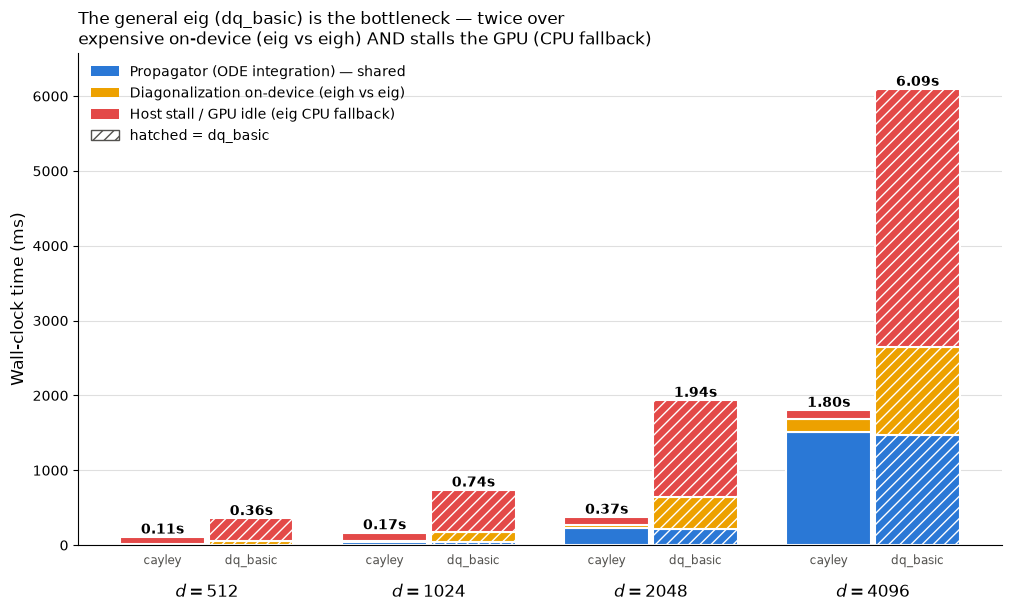

In [9]:
# No-flag data: profiler attributes device time faithfully here.
nf_data = np.load('../out_withoutXLA_flag/gpu_h200.npy', allow_pickle=True).item()

def eig_decomp(runs_by_dim, diag_prefix):
    """Return dims and (propagator, diagonalization, host_stall) means in ms."""
    dims = sorted(runs_by_dim)
    prop, diag, stall = [], [], []
    for d in dims:
        rows = runs_by_dim[d]
        wall = np.mean([r['t_total'] for r in rows]) * 1e3
        dev  = np.mean([r['device_busy_ns'] for r in rows]) / 1e6
        dg   = np.mean([sum(v for k, v in r['op_self_ns'].items()
                            if k.startswith(diag_prefix)) for r in rows]) / 1e6
        prop.append(dev - dg); diag.append(dg); stall.append(wall - dev)
    return dims, np.array(prop), np.array(diag), np.array(stall)

def plot_eig_bottleneck(data_for_device, plot_dims=(512, 1024, 2048, 4096), fontsize=12):
    # validated categorical slots: blue (shared work) / yellow (diag) / red (the stall = harm)
    C_PROP, C_DIAG, C_STALL = '#2a78d6', '#eda100', '#e34948'
    diag_prefix = {'dq_basic': 'eig.', 'cayley': 'eigh.'}

    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    x = np.arange(len(plot_dims)); w = 0.38
    hatches = {'dq_basic': '///', 'cayley': None}
    offsets = {'cayley': -w/2 - 0.01, 'dq_basic': w/2 + 0.01}
    ymax = 0

    for solver in SOLVERS:
        dims, prop, diag, stall = eig_decomp(data_for_device[solver], diag_prefix[solver])
        idx = [dims.index(d) for d in plot_dims]
        prop, diag, stall = prop[idx], diag[idx], stall[idx]
        wall = prop + diag + stall; ymax = max(ymax, wall.max())
        xs = x + offsets[solver]; h = hatches[solver]
        ax.bar(xs, prop,  w, color=C_PROP,  edgecolor='white', linewidth=1.5, hatch=h)
        ax.bar(xs, diag,  w, bottom=prop, color=C_DIAG, edgecolor='white', linewidth=1.5, hatch=h)
        ax.bar(xs, stall, w, bottom=prop + diag, color=C_STALL, edgecolor='white', linewidth=1.5, hatch=h)
        for xi, wl in zip(xs, wall):
            ax.text(xi, wl, f'{wl/1e3:.2f}s', ha='center', va='bottom',
                    fontsize=fontsize - 2, fontweight='bold')
        for xi in xs:
            ax.text(xi, -0.02 * ymax, solver, ha='center', va='top',
                    fontsize=fontsize - 3.5, color='#52514e')

    ax.set_xticks(x); ax.set_xticklabels([f'$d = {d}$' for d in plot_dims], fontsize=fontsize)
    ax.tick_params(axis='x', length=0, pad=28)
    ax.set_ylabel('Wall-clock time (ms)', fontsize=fontsize)
    ax.set_ylim(0, ymax * 1.08)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    ax.grid(True, axis='y', alpha=0.4); ax.set_axisbelow(True)
    ax.set_title('The general eig (dq_basic) is the bottleneck — twice over\n'
                 'expensive on-device (eig vs eigh) AND stalls the GPU (CPU fallback)',
                 fontsize=fontsize, loc='left')

    from matplotlib.patches import Patch
    legend = [Patch(fc=C_PROP,  label='Propagator (ODE integration) — shared'),
              Patch(fc=C_DIAG,  label='Diagonalization on-device (eigh vs eig)'),
              Patch(fc=C_STALL, label='Host stall / GPU idle (eig CPU fallback)'),
              Patch(fc='none', hatch='///', ec='#52514e', label='hatched = dq_basic')]
    ax.legend(handles=legend, loc='upper left', frameon=False, fontsize=fontsize - 2)
    plt.show()

plot_eig_bottleneck(nf_data)

## Inside the propagator phase — what the ODE integration actually does

The propagator phase (the shared blue block above) is itself a mix of kernels. Splitting it by
kind — across dimension — shows the loop shifting from **overhead-bound** to **compute-bound**:

- **GEMM** — the complex O(d³) matmuls that apply H(t) to the propagator (the physics).
- **Tsit5 stage combine** — the elementwise Butcher-tableau sums (memory-bandwidth-bound).
- **buffer/slice bookkeeping** and **adaptive step control** — the integrator's machinery.

GEMM's share climbs from ~20% at d=128 to ~77% at d=4096: at large `d` the propagator is
almost pure matmul, which is why a fixed-step method (removing the ~20% overhead) helps most at
*small* `d`, and why the CUDA-graph flag — which only cuts launch latency — buys nothing at d=4096.

The per-kernel categories live inside the trace files, not in `op_self_ns`, so this is
precomputed into `out/propagator_breakdown.npy` by `profiling.py` (at the repo root).
Regenerate it with `uv run python profiling.py` if the traces change.

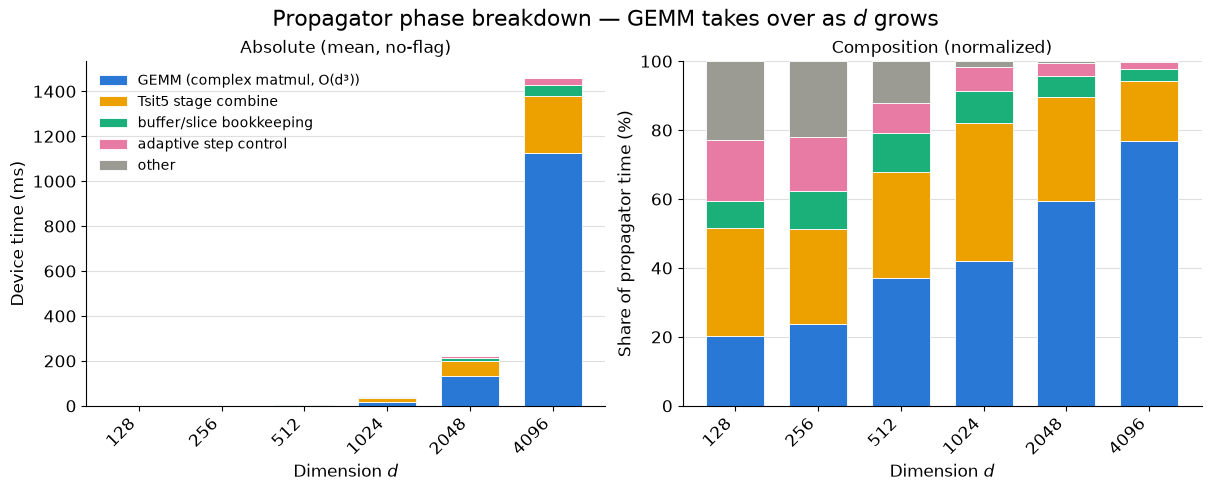

In [10]:
# Precomputed from the no-flag traces (kernel categories aren't in op_self_ns).
prop_bd = np.load('propagator_breakdown.npy', allow_pickle=True).item()

# fixed category order (bottom -> top) with validated palette slots
PROP_CATS = [
    ('GEMM (complex matmul, O(d³))', '#2a78d6'),  # blue  - the physics
    ('Tsit5 stage combine',          '#eda100'),  # yellow
    ('buffer/slice bookkeeping',     '#1baf7a'),  # aqua
    ('adaptive step control',        '#e87ba4'),  # magenta
    ('other',                        '#9c9b93'),  # gray
]

def plot_propagator_breakdown(breakdown, fontsize=12):
    dims = sorted(breakdown)
    x = np.arange(len(dims))
    cats   = [c for c, _ in PROP_CATS]
    colors = [c for _, c in PROP_CATS]
    # table[cat] = array over dims (ms)
    table = {c: np.array([breakdown[d].get(c, 0.0) for d in dims]) for c in cats}
    totals = sum(table.values())

    fig, axs = plt.subplots(1, 2, figsize=(6 * 2, 4.8), constrained_layout=True)

    for ax, normalize in zip(axs, (False, True)):
        bottom = np.zeros(len(dims))
        for c, col in zip(cats, colors):
            vals = table[c]
            share = np.divide(vals, totals, out=np.zeros_like(totals), where=totals > 0) * 100 \
                    if normalize else vals
            ax.bar(x, share, bottom=bottom, width=0.7, color=col, label=c,
                   edgecolor='white', linewidth=0.6)
            bottom += share
        ax.set_xlabel('Dimension $d$', fontsize=fontsize)
        ax.set_xticks(x); ax.set_xticklabels(dims, rotation=45, ha='right')
        ax.tick_params(axis='both', labelsize=fontsize)
        ax.grid(True, axis='y', alpha=0.4); ax.set_axisbelow(True)
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
        if normalize:
            ax.set_ylabel('Share of propagator time (%)', fontsize=fontsize)
            ax.set_ylim(0, 100)
            ax.set_title('Composition (normalized)', fontsize=fontsize)
        else:
            ax.set_ylabel('Device time (ms)', fontsize=fontsize)
            ax.set_title('Absolute (mean, no-flag)', fontsize=fontsize)

    axs[0].legend(fontsize=fontsize - 2, loc='upper left', frameon=False)
    fig.suptitle('Propagator phase breakdown — GEMM takes over as $d$ grows',
                 fontsize=1.3 * fontsize)
    plt.show()

plot_propagator_breakdown(prop_bd)